##Importación de Librerías y Carga de Datos

Primero, necesitamos cargar las herramientas y las tablas procesadas. Las tablas clave aquí son fact_ventas.csv (para el comportamiento de compra) y dim_cliente.csv (para los datos demográficos).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado y Evaluación
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Fijamos la semilla para reproducibilidad (requerimiento del proyecto)
RANDOM_STATE = 42

# Carga de datos (ajusta la ruta según tu estructura local)
# Asumiendo que el separador de los CSVs generados es ';'
ventas = pd.read_csv('../data/processed/fact_ventas.csv', sep=';')
clientes = pd.read_csv('../data/processed/dim_cliente.csv', sep=';')

# Aseguramos que la fecha sea tipo datetime
ventas['fecha'] = pd.to_datetime(ventas['fecha'])

##Feature Engineering y Variable Objetivo

Necesitamos traducir el historial transaccional en un perfil por cliente (RFM: Recencia, Frecuencia, Monto) y definir qué es "abandono".

In [9]:
# Definimos "hoy" como la fecha máxima en nuestra base de ventas
fecha_actual = ventas['fecha'].max()

# Calculamos el importe por línea de venta
ventas['importe'] = ventas['cantidad'] * ventas['precio_unitario_lista'] * (1 - ventas['descuento_pct'].fillna(0))

# Agrupamos por cliente para obtener sus métricas RFM
rfm = ventas.groupby('id_cliente').agg(
    recencia=('fecha', lambda x: (fecha_actual - x.max()).days),
    frecuencia=('id_venta', 'nunique'),
    monto_total=('importe', 'sum'),
    dias_desde_primera_compra=('fecha', lambda x: (fecha_actual - x.min()).days)
).reset_index()

# Definimos la variable objetivo: Abandono (Churn)
# Regla de negocio propuesta: Si no ha comprado en los últimos 180 días (6 meses), se considera abandono = 1
UMBRAL_ABANDONO = 180
rfm['abandono'] = (rfm['recencia'] >= UMBRAL_ABANDONO).astype(int)

# Unimos con la dimensión cliente para agregar características demográficas
df_analitico = pd.merge(rfm, clientes[['id_cliente', 'sexo', 'distrito', 'segmento_programa']], on='id_cliente', how='inner')

# Convertimos variables categóricas a variables dummy (One-Hot Encoding)
df_model = pd.get_dummies(df_analitico, columns=['sexo', 'distrito', 'segmento_programa'], drop_first=True)

##Análisis Exploratorio Rápido (EDA)

Es crucial entender el desbalance de clases antes de entrenar los modelos.

Distribución de Clientes (0 = Activo, 1 = Abandono):
abandono
0    75.82
1    24.18
Name: proportion, dtype: float64


/tmp/ipykernel_4159/2201556235.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_model, x='abandono', palette='viridis')


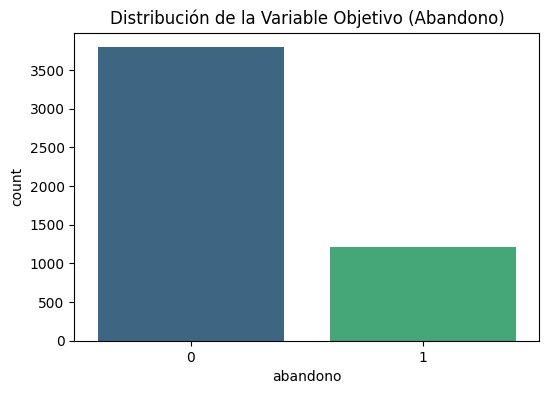

In [10]:
# Vemos la distribución de la variable objetivo
print("Distribución de Clientes (0 = Activo, 1 = Abandono):")
print(df_model['abandono'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(data=df_model, x='abandono', palette='viridis')
plt.title('Distribución de la Variable Objetivo (Abandono)')
plt.show()

##Preparación y División de los Datos
Separamos las características ($X$) de la etiqueta ($y$) y dividimos en conjunto de entrenamiento y prueba de manera estratificada.

In [11]:
# Separamos features (X) y target (y)
# Excluimos id_cliente porque no es predictivo, y recencia porque tiene correlación directa con la creación de la etiqueta
X = df_model.drop(columns=['id_cliente', 'abandono', 'recencia'])
y = df_model['abandono']

# División estratificada 75/25
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

# Escalamos los datos (muy importante para la Regresión Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##Entrenamiento y Comparación de Modelos

Entrenaremos tres modelos, utilizando el parámetro class_weight='balanced' para manejar la diferencia entre clientes activos y los que abandonan.

In [12]:
# Inicializamos los modelos
modelos = {
    "Regresión Logística": LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced'),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced', max_depth=5),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced', n_estimators=100)
}

# Entrenamos y evaluamos
resultados = {}

for nombre, modelo in modelos.items():
    # Usamos datos escalados para regresión logística, para árboles no es estrictamente necesario pero no afecta
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]

    auc = roc_auc_score(y_test, y_proba)
    resultados[nombre] = auc

    print(f"--- {nombre} ---")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {auc:.3f}\n")

--- Regresión Logística ---
[[705 243]
 [ 70 232]]
              precision    recall  f1-score   support

           0       0.91      0.74      0.82       948
           1       0.49      0.77      0.60       302

    accuracy                           0.75      1250
   macro avg       0.70      0.76      0.71      1250
weighted avg       0.81      0.75      0.76      1250

ROC-AUC: 0.828

--- Árbol de Decisión ---
[[712 236]
 [ 85 217]]
              precision    recall  f1-score   support

           0       0.89      0.75      0.82       948
           1       0.48      0.72      0.57       302

    accuracy                           0.74      1250
   macro avg       0.69      0.73      0.70      1250
weighted avg       0.79      0.74      0.76      1250

ROC-AUC: 0.815

--- Random Forest ---
[[867  81]
 [179 123]]
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       948
           1       0.60      0.41      0.49       302

    a

##Exportación para Power BI

Seleccionamos el mejor modelo (usualmente Random Forest) para generar las predicciones sobre toda la base y exportarlo para que el Arquitecto BI pueda crear la página de "Riesgo de Abandono".

In [14]:
# Asumiendo que Random Forest dio los mejores resultados
mejor_modelo = modelos['Random Forest']

# Predecimos la probabilidad sobre toda la base (X original escalado)
X_total_scaled = scaler.transform(X)
df_analitico['probabilidad_abandono'] = mejor_modelo.predict_proba(X_total_scaled)[:, 1]
df_analitico['riesgo'] = pd.cut(df_analitico['probabilidad_abandono'], bins=[0, 0.3, 0.7, 1.0], labels=['Bajo', 'Medio', 'Alto'])

# Seleccionamos las columnas para exportar a Power BI
export_pbi = df_analitico[['id_cliente', 'probabilidad_abandono', 'riesgo']]

# Exportamos a CSV
ruta_salida = '../data/processed/predicciones_abandono.csv'
export_pbi.to_csv(ruta_salida, sep=';', index=False)
print(f"Predicciones exportadas exitosamente a {ruta_salida}")

Predicciones exportadas exitosamente a predicciones_abandono.csv
